## Analyse contrail forcing
- Take gridded contrail forcing output explained in `helpers\contrail_forcing_gridded_output_description.xlsx`
- Convert tabular parquet files to netcdf using `helpers\launch_conversion`
- Aggregate by hour, month and year

## Data availability

### Parquet files

In [ ]:
import os
import pandas as pd
from datetime import datetime

# --- CONFIG ---
# Path to your folder containing .pq files
FOLDER_PATH = "./"
# Path to the output CSV
OUTPUT_CSV = "forcing_pq_file_availability.csv"

# --- MAIN SCRIPT ---
data = []

# List all files in the directory
for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".pq"):
        filepath = os.path.join(FOLDER_PATH, filename)
        # Extract date from filename (assuming format YYYYMMDD.pq)
        try:
            date_str = filename.replace(".pq", "")
            date = datetime.strptime(date_str, "%Y%m%d").date()
        except ValueError:
            # Skip any files not matching the pattern
            continue
        
        availability = os.path.exists(filepath)
        data.append({
            "filename": filename,
            "date": date,
            "availability": availability
        })

# Convert to DataFrame
df = pd.DataFrame(data)

# Sort by date
df = df.sort_values(by="date")

# Save to CSV
df.to_csv(OUTPUT_CSV, index=False)

print(f"CSV written to {OUTPUT_CSV} with {len(df)} entries.")


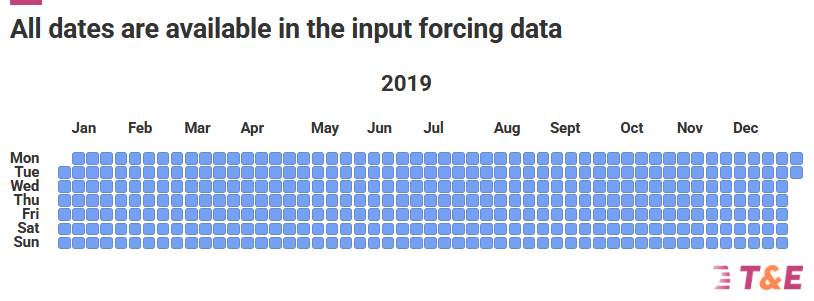

## conversion.py

- Adapt convert_parquet_to_netcdf.py to gridded forcing data and only keep fields relevant for this analysis
- Convert to 4 byte floating point numbers to save memory - this entails a loss of accuracy that I deem acceptable for this type of analysis

In [ ]:
"""
Convert contrail parquet data to hourly NetCDF (4D: lon-lat-alt-time).
"""

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import sys
from tqdm import tqdm
import os 

# ----------- USER INPUTS ----------- #

FOLDER_PATH = "./"        # Folder with daily parquet files
OUTPUT_PATH = "cdf/"      # Folder to save hourly netcdf files

# CLI arguments: start and end date (inclusive)
if len(sys.argv) >= 3:
    DATE_START = sys.argv[1]
    DATE_END = sys.argv[2]
else:
    print("Usage: python script.py YYYY-MM-DD YYYY-MM-DD")
    sys.exit(1)

TEMPORAL_RES_H = 1  # 1-hour resolution

# Altitude dimension (m)
ALTITUDE_BOUNDS_M = (6000.0, 15000.0)
ALTITUDE_RES_M = 304.8

# Longitude-latitude dimension (degrees)
SPATIAL_BBOX = (-180.0, -90.0, 180.0, 90.0)
SPATIAL_GRID_RES = 0.25

# ----------- FUNCTIONS ----------- #

def _agg_to_grid(df_res, agg_map, lon_coords, lat_coords, alt_coords):
    shape = lon_coords.size, lat_coords.size, alt_coords.size

    idx_lon = np.searchsorted(lon_coords, df_res["longitude"])
    idx_lat = np.searchsorted(lat_coords, df_res["latitude"])
    idx_alt = np.searchsorted(alt_coords, df_res["altitude"])

    df_agg = df_res.groupby([idx_lon, idx_lat, idx_alt]).agg(agg_map)
    i0, i1, i2 = df_agg.index.get_level_values(0), df_agg.index.get_level_values(1), df_agg.index.get_level_values(2)
    ds = xr.Dataset(coords={"longitude": lon_coords, "latitude": lat_coords, "altitude": alt_coords})

    for name, col in df_agg.items():
        arr = np.zeros(shape, dtype=np.float32)
        arr[i0, i1, i2] = col.astype(np.float32)
        ds[name] = (("longitude", "latitude", "altitude"), arr)

    return ds


def _convert_daily_to_hourly(date: pd.Timestamp):
    date_str = date.strftime("%Y%m%d")
    file_path = f"{FOLDER_PATH}/{date_str}.pq"
    df_res = pd.read_parquet(file_path)

    # Downcast floats
    float_cols = df_res.select_dtypes(include=['float64']).columns
    df_res[float_cols] = df_res[float_cols].astype('float32')

    df_res['new_contrail_length'] = df_res['new_contrail_length'].fillna(0)

    # Filter by spatial and altitude bounds
    west, south, east, north = SPATIAL_BBOX
    df_res = df_res[
        df_res["longitude"].between(west, east)
        & df_res["latitude"].between(south, north)
        & df_res["altitude"].between(*ALTITUDE_BOUNDS_M)
    ].copy()

    # Coordinates
    lon_coords = np.arange(west, east + 0.01, SPATIAL_GRID_RES)
    lat_coords = np.arange(south, north + 0.01, SPATIAL_GRID_RES)
    alt_coords = np.arange(ALTITUDE_BOUNDS_M[0], ALTITUDE_BOUNDS_M[1] + ALTITUDE_RES_M, ALTITUDE_RES_M)
    df_res["hour"] = df_res["hour"].round().astype(int)

    # Time slices
    time_slices = np.arange(0, 25, TEMPORAL_RES_H)
    for t in range(len(time_slices) - 1):
        h_start, h_end = time_slices[t], time_slices[t + 1]
        filt = df_res["hour"].between(h_start, h_end, inclusive="left")
        df_hour = df_res[filt].copy()
        if len(df_hour) == 0:
            continue
        _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords)


def _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords):

    # Build expected output filename early
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"

    # --- 🔍 Check if output already exists
    #if os.path.exists(output_file):
    #    print(f"⏩ Skipping existing file: {output_file}")
    #    return  # Nothing to do


    # Aggregations
    agg_map_1 = {
        'total_flight_dist': 'sum',
        #'new_contrail_length': 'sum',
        'contrail_ef_initial_loc': 'sum',
        'contrail_ef_overlap_initial_loc': 'sum',
    }
    ds_agg_1 = _agg_to_grid(df_hour, agg_map_1, lon_coords, lat_coords, alt_coords)

    #filt2 = df_hour["tau_contrail_area"].notna()
    #agg_map_2 = {'total_contrail_length': 'sum'}
    #ds_agg_2 = _agg_to_grid(df_hour[filt2], agg_map_2, lon_coords, lat_coords, alt_coords)

    filt3 = df_hour["contrail_ef"].notna()
    agg_map_3 = {
        'contrail_ef': 'sum',
        #'contrail_ef_sw': 'sum',
        #'contrail_ef_lw': 'sum',
        'contrail_ef_overlap': 'sum',
        #'contrail_ef_sw_overlap': 'sum',
        #'contrail_ef_lw_overlap': 'sum',
    }
    ds_agg_3 = _agg_to_grid(df_hour[filt3], agg_map_3, lon_coords, lat_coords, alt_coords)

    #filt4 = df_hour["mean_contrail_age"].notna()
    #df_hour["n"] = np.where(df_hour["tau_contrail_area"] > 0, 1, 0)
    #agg_map_4 = {
    #    'mean_contrail_age': 'mean',
    #    'tau_contrail_area': 'sum',
    #    'n': 'count',
    #}
    #ds_agg_4 = _agg_to_grid(df_hour[filt4], agg_map_4, lon_coords, lat_coords, alt_coords)
    #da_area = grid_surface_area(lon_coords, lat_coords)
    #ds_agg_4["tau_contrail"] = ds_agg_4["tau_contrail_area"] / (da_area * ds_agg_4["n"])

    # Merge hourly datasets
    ds = xr.Dataset(
        data_vars=dict(
            total_flight_dist=(["longitude", "latitude", "altitude"], ds_agg_1["total_flight_dist"].values / 1000),
            #new_contrail_length=(["longitude", "latitude", "altitude"], ds_agg_1["new_contrail_length"].values / 1000),
            #total_contrail_length=(["longitude", "latitude", "altitude"], ds_agg_2["total_contrail_length"].values / 1000),
            #tau_contrail=(["longitude", "latitude", "altitude"], ds_agg_4["tau_contrail"].values.astype('float32')),
            #mean_contrail_age=(["longitude", "latitude", "altitude"], ds_agg_4["mean_contrail_age"].values.astype('float32')),
            #ef_sw=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef_sw"].values),
            #ef_lw=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef_lw"].values),
            ef_net=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef"].values),
            ef_initial_loc=(["longitude", "latitude", "altitude"], ds_agg_1["contrail_ef_initial_loc"].values),
            #ef_sw_overlap=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef_sw_overlap"].values),
            #ef_lw_overlap=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef_lw_overlap"].values),
            ef_net_overlap=(["longitude", "latitude", "altitude"], ds_agg_3["contrail_ef_overlap"].values),
            ef_initial_loc_overlap=(["longitude", "latitude", "altitude"], ds_agg_1["contrail_ef_overlap_initial_loc"].values),
        ),
        coords=dict(longitude=lon_coords, latitude=lat_coords, altitude=alt_coords)
    )

    # Add time dimension
    t_mid = date + pd.Timedelta(hours=h_start + TEMPORAL_RES_H / 2)
    ds = ds.expand_dims().assign_coords({"time": t_mid})

    # Compression and saving
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"


    comp = dict(zlib=True, complevel=4, dtype='float32')
    encoding = {var: comp for var in ds.data_vars}
    ds.to_netcdf(output_file, encoding=encoding)
    print(f"✅ Saved {output_file}")


def main():
    dates = pd.date_range(DATE_START, DATE_END, freq="1D")
    for date in tqdm(dates, desc="Processing days"):
        _convert_daily_to_hourly(date)


if __name__ == "__main__":
    main()


## Netcdf files after conversion
I am checking this since the netcdf file writer often fails (writes files only containing zeros) and I needed to run it several times for all files to be written correctly (hopefully). 


In [ ]:
import os
import re
import pandas as pd
from datetime import datetime

# --- CONFIG ---
FOLDER_PATH = "/path/to/your/cdf/folder"
OUTPUT_CSV = "daily_nc_availability.csv"

# --- MAIN SCRIPT ---
pattern = re.compile(r"(\d{8})-(\d{2})-(\d{2})-contrail\.nc$")

# Dictionary to store available hours per day
availability = {}

for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".nc"):
        match = pattern.search(filename)
        if not match:
            continue

        date_str, hour_start, hour_end = match.groups()
        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Record availability for that hour
        availability.setdefault(date, set()).add(int(hour_start))

# Build a list of rows for the CSV
rows = []
for date, hours in sorted(availability.items()):
    total_hours_available = len(hours)
    share = total_hours_available / 24  # Share of day covered
    rows.append({
        "date": date,
        "filename_pattern": f"{date.strftime('%Y%m%d')}-*-*-contrail.nc",
        "availability_share": round(share, 3)
    })

# Convert to DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Wrote {OUTPUT_CSV} with {len(df)} days of data.")


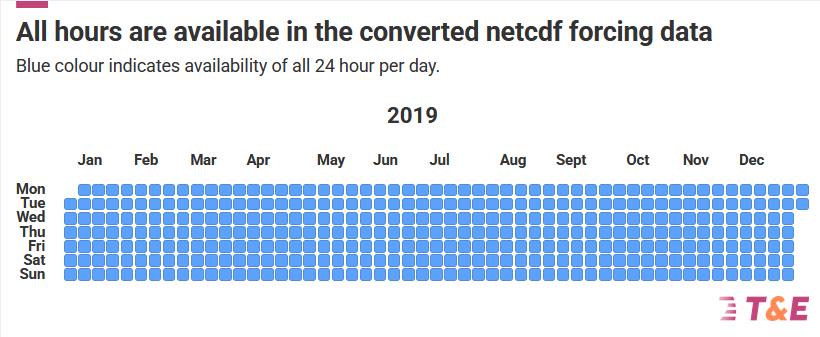

## aggregate.py
- sum all numerical variables in netcdf input files and write to outfile with compression
- make sure that grids coincide

In [ ]:
import sys
import xarray as xr
import os

OUTFILE = sys.argv[1]
FILES = sys.argv[2:]

def aggregate(files, outfile):
    running_sum = None
    for f in files:
        try:
            ds = xr.open_dataset(f, engine="netcdf4", decode_timedelta=False)
            print(f"Processing {f} with vars: {ds.data_vars}")
            ds = ds.fillna(0).squeeze(drop=True)
            ds = ds.drop_vars("hour", errors="ignore")
            if running_sum is None:
                running_sum = ds.astype("float32")
            else:
                running_sum = running_sum + ds.astype("float32")
            ds.close()
        except Exception as e:
            print(f"⚠️ Error reading {f}: {e}")

    if running_sum is not None:
        encoding = {
            var: {"zlib": True, "complevel": 4, "dtype": "float32"}
            for var in running_sum.data_vars
        }
        running_sum.to_netcdf(outfile, encoding=encoding)
        print(f"✅ Saved {outfile}")

if __name__ == "__main__":
    if not FILES:
        print("No files given.")
        sys.exit(1)
    aggregate(FILES, OUTFILE)


## launch_aggregation.py

- read hourly netcdf files for the entire year and sum them by hour, month and finally year

In [ ]:
#!/usr/bin/env python3
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

# ================= CONFIG ==================
INDIR = "cdf/"
OUTDIR = "aggregated"
os.makedirs(OUTDIR, exist_ok=True)
N_WORKERS = 12  # Adjust for your CPU / cluster
# ===========================================

def parse_time(fname):
    """Parse filenames like 20190101-11-12-gaia.nc -> datetime(2019,1,1,11)."""
    base = os.path.basename(fname).replace(".nc", "")
    parts = base.split("-")
    if len(parts) >= 4 and parts[-1] == "contrail":
        date_str = parts[0]  # 20190101
        hour_str = parts[1]  # 11 (start hour)
        dt = datetime.strptime(f"{date_str}{hour_str}", "%Y%m%d%H")
        return dt
    raise ValueError(f"Unexpected filename format: {fname}")

def call_worker(outpath, files):
    """Run the external aggregation script."""
    if not files:
        print(f"⚠️ No input files for {outpath}, skipping.")
        return None
    
    try:
        subprocess.run(
            ["python", "aggregate.py", outpath] + files,
            check=True
        )
        return outpath
    except subprocess.CalledProcessError as e:
        print(f"❌ Failed to aggregate {outpath}: {e}")
        return None

def launch_parallel_aggregate(jobs, desc):
    """
    Run a batch of call_worker tasks in parallel.
    jobs: list of tuples (outpath, files)
    desc: str, description for logging
    Returns: list of successful outpaths
    """
    results = []
    if not jobs:
        print(f"⚠️ No jobs to run for {desc}.")
        return results

    print(f"🚀 Launching {len(jobs)} {desc} jobs using {N_WORKERS} workers...")
    #for out, flist in jobs:
    #    call_worker(out, flist)
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        future_map = {executor.submit(call_worker, out, flist): out for out, flist in jobs}
        for fut in as_completed(future_map):
            outpath = future_map[fut]
            res = fut.result()
            if res:
                results.append(res)
                print(f"✅ Done: {os.path.basename(outpath)}")
            else:
                print(f"⚠️ Skipped or failed: {os.path.basename(outpath)}")
    print(f"✅ Completed all {desc} jobs.\n")
    return results

def main():
    # === STEP 1: Gather input files ===
    nc_files = sorted([
        os.path.join(INDIR, f)
        for f in os.listdir(INDIR)
        if f.endswith(".nc") and "-contrail" in f
    ])
    print(f"📦 Found {len(nc_files)} input files.")

    print("Processing hourly sums per month")
    # === STEP 2: Hourly sums per month ===
    hourly_jobs = []
    for month in range(1, 13):
        for hour in range(0, 24):
            files = [f for f in nc_files if parse_time(f).month == month and parse_time(f).hour == hour]
            if not files:
                continue
            outname = f"hourly_sum_m{month:02d}_h{hour:02d}.nc"
            outpath = os.path.join(OUTDIR, outname)
            hourly_jobs.append((outpath, files))

    print(f"Calling launch_parallel_aggregate with {len(hourly_jobs)}")
    hourly_by_month_files = {}
    hourly_results =  [outpath for outpath, files in hourly_jobs]# launch_parallel_aggregate(hourly_jobs, "hourly (month-hour)") #
    for outpath in hourly_results:
        name = os.path.basename(outpath)
        parts = name.replace("hourly_sum_m", "").replace(".nc", "").split("_h")
        month = int(parts[0])
        hour = int(parts[1])
        hourly_by_month_files[(month, hour)] = outpath

    print("Computing monthly sums!")

    # === STEP 3: Monthly sums ===
    monthly_jobs = []
    for month in range(1, 13):
        files = [hourly_by_month_files[(month, h)] for h in range(24) if (month, h) in hourly_by_month_files]
        if not files:
            continue
        outname = f"monthly_sum_{month:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        monthly_jobs.append((outpath, files))

    monthly_results = launch_parallel_aggregate(monthly_jobs, "monthly")
    monthly_files = {int(os.path.basename(f).split("_")[2].split(".")[0]): f for f in monthly_results}


    # === STEP 4: Annual sum ===
    if monthly_files:
        annual_out = os.path.join(OUTDIR, "annual_sum.nc")
        print(f"→ Aggregating annual sum from {len(monthly_files)} monthly files...")
        call_worker(annual_out, list(monthly_files.values()))
    else:
        print("⚠️ Skipping annual sum — no monthly files found.")


    # === STEP 5: Hourly means across all months ===
    hourly_across_jobs = []
    for hour in range(0, 24):
        files = [hourly_by_month_files[(m, hour)] for m in range(1, 13) if (m, hour) in hourly_by_month_files]
        if not files:
            continue
        outname = f"annual_hourly_sum_{hour:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        hourly_across_jobs.append((outpath, files))

    launch_parallel_aggregate(hourly_across_jobs, "hourly-across-months")

    print("🎉 All aggregations complete.")

if __name__ == "__main__":
    main()

## Compute statistics directly from pq files

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import regionmask
import json, topojson
import glob, re
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import datetime

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
COLS_SUM = [
    "total_flight_dist", 
    "contrail_ef_initial_loc",
    "contrail_ef_overlap_initial_loc", 
    "new_contrail_length", 
    "total_contrail_length", 
    "tau_contrail_area", 
    "mean_contrail_age", 
    "contrail_ef", 
    "contrail_ef_sw", 
    "contrail_ef_lw", 
    "contrail_ef_overlap", 
    "contrail_ef_sw_overlap", 
    "contrail_ef_lw_overlap"
]


def build_regionmask():
    """Builds a combined regionmask from FIRs."""

    
    # Load the combined GeoDataFrame
    gdf_combined = gpd.read_file("airspaces.geojson").set_crs(epsg=4326)

    # Build the region mask
    combined_mask = regionmask.Regions(
        outlines=gdf_combined.geometry.values,
        names=gdf_combined["name"].tolist(),
        abbrevs=gdf_combined["name"].tolist()
    )

    return combined_mask


def process_file(file, mask):
    """Processes a single parquet file for all FIR/regions."""
    import pandas as pd
    import geopandas as gpd
    from shapely.geometry import Point
    import re

    fname = Path(file).stem
    m = re.search(r"(\d{8})", fname)
    date = pd.Timestamp(m.group(1)) if m else pd.NaT

    df = pd.read_parquet(file).fillna(0)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")

    results = []
    for region_id, region_name in enumerate(mask.names):
        print("Processing: ", region_name)
        geom = mask[region_id].polygon
        minx, miny, maxx, maxy = geom.bounds
        subset = gdf.cx[minx:maxx, miny:maxy]
        subset = subset[subset.geometry.within(geom)]
        if subset.empty:
            continue

        df_hourly = subset.groupby("hour")[COLS_SUM].sum(min_count=1).reset_index()
        df_hourly["timestamp"] = [date + pd.Timedelta(hours=int(h)) for h in df_hourly["hour"]]
        df_hourly["region"] = region_name
        df_hourly["file"] = Path(file).name
        results.append(df_hourly)

    return pd.concat(results, ignore_index=True) if results else None


def main():
    """Main entry point for multiprocessing FIR analysis."""
    folder_path = "./"
    pq_files = sorted(glob.glob(f"{folder_path}/*.pq"))

    n_workers = 4  # Adjust to CPU cores

    if not pq_files:
        print("❌ No parquet files found!")
        return

    print(f"Found {len(pq_files)} parquet files")
    mask = build_regionmask()

    results = []
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(process_file, f, mask): f for f in pq_files}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Processing files"):
            try:
                df_res = fut.result()
                if df_res is not None:
                    results.append(df_res)
            except Exception as e:
                print(f"⚠️ Error processing {futures[fut]}: {e}")

    if not results:
        print("❌ No data processed!")
        return

    df_all = pd.concat(results, ignore_index=True)
    output_path = Path("hourly_totals_by_region_subset.pq")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(output_path, index=False)
    print(f"✅ Multiprocessing complete. Results saved to {output_path}")


if __name__ == "__main__":
    main()


## Global statistics

In [20]:
import xarray as xr 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")

In [5]:
ds

<xarray.Dataset> Size: 644MB
Dimensions:                 (longitude: 1441, latitude: 721, altitude: 31)
Coordinates:
  * longitude               (longitude) float64 12kB -180.0 -179.8 ... 180.0
  * latitude                (latitude) float64 6kB -90.0 -89.75 ... 89.75 90.0
  * altitude                (altitude) float64 248B 6e+03 ... 1.514e+04
Data variables:
    total_flight_dist       (longitude, latitude, altitude) float32 129MB ...
    ef_net                  (longitude, latitude, altitude) float32 129MB ...
    ef_initial_loc          (longitude, latitude, altitude) float32 129MB ...
    ef_net_overlap          (longitude, latitude, altitude) float32 129MB ...
    ef_initial_loc_overlap  (longitude, latitude, altitude) float32 129MB ...

In [59]:
ds["forcing_per_dist"] = ds["ef_initial_loc_overlap"] / ds["total_flight_dist"]

In [48]:
import pandas as pd 

# These definitions follow the bounding boxes in Teoh et al.'s paper (except for Eurocontrol)
regions = {
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "Eurocontrol": {"lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "Eurocontrol + North Atlantic": {"lon_min": -70.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset


In [ ]:

regional_stats = {}

for name, bbox in regions.items():
    ds_region = subset_region(ds, bbox)
    stats = {
        "Energy forcing (x 10^18 J)": round(float(ds_region["ef_initial_loc_overlap"].sum().values)/1e18, 1),
        "Flight distance (x 10^9 km)": round(float(ds_region["total_flight_dist"].sum().values)/1e9, 1)
    }
    regional_stats[name] = stats

df = pd.DataFrame(regional_stats)
df.to_csv("output/forcing/3_statistics.csv")
df

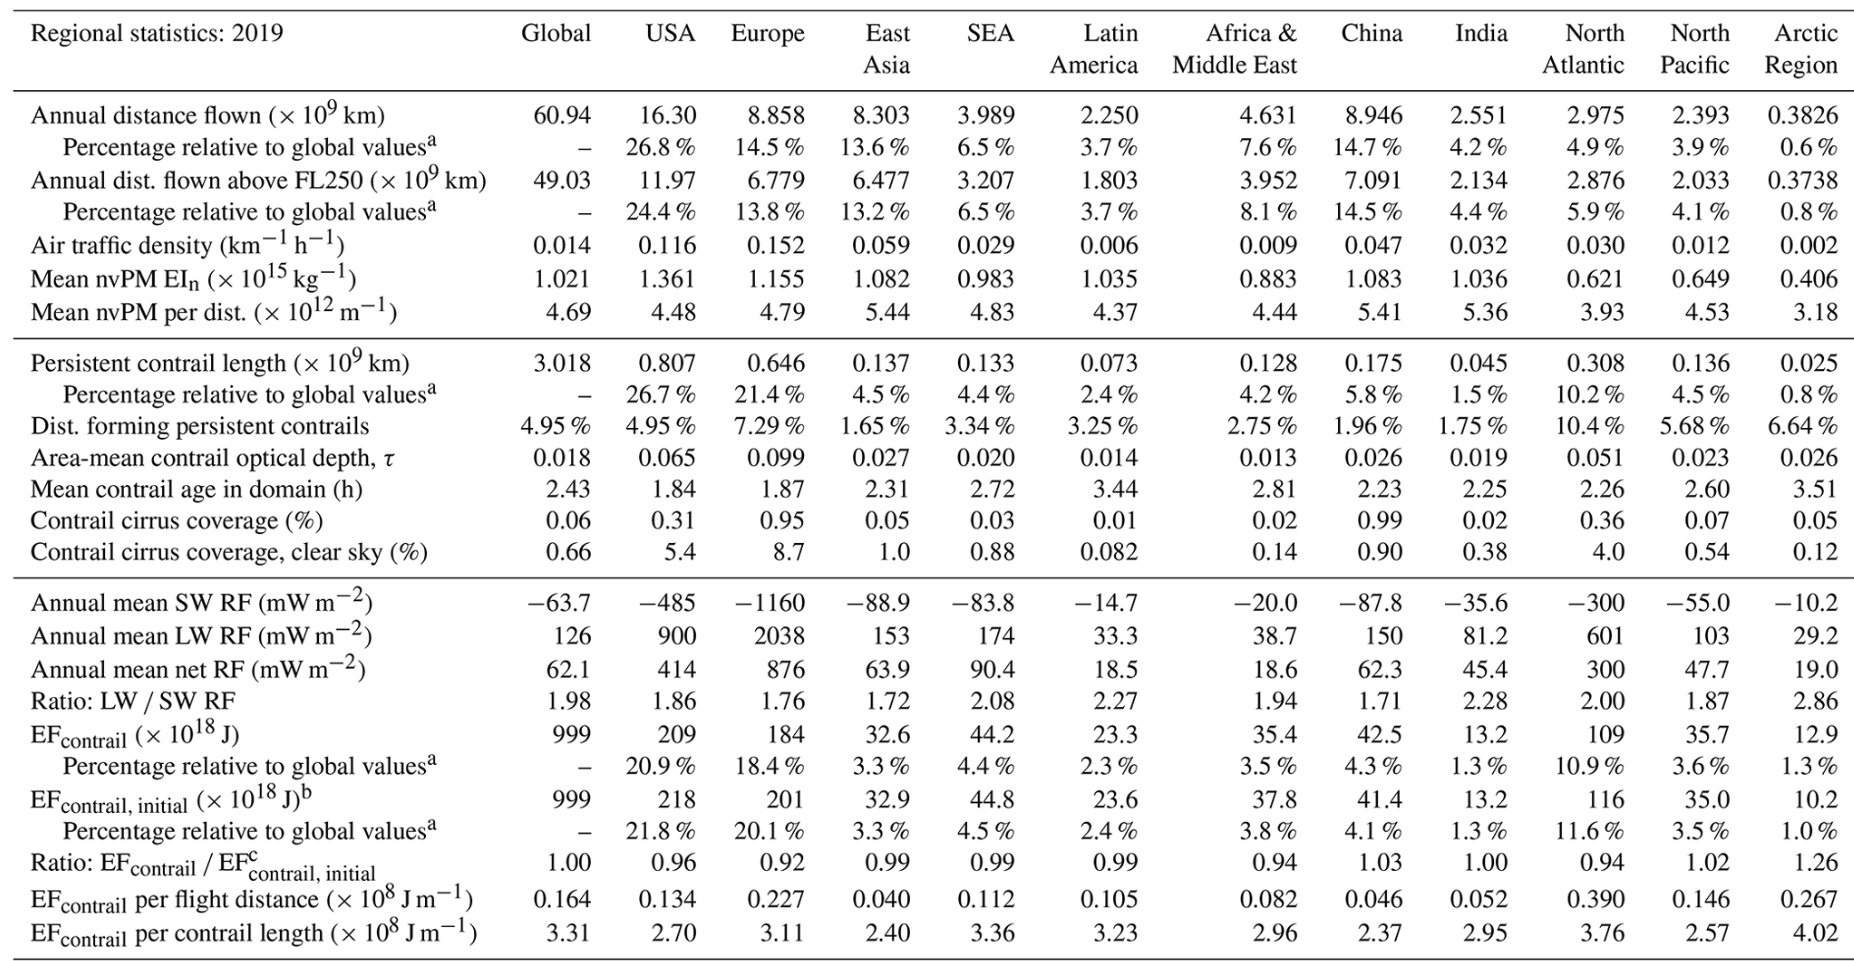

In [ ]:
import pandas as pd

# These hourly totals are obtained by directly summing the parquet files without the grid
# This should be less prone to bugs in the code than the above approach and give better results
df = pd.read_csv("data/gridded_forcing/hourly_totals.csv")
df.head()

In [24]:
f'We find {round(df["total_flight_dist"].sum()/1e12, 1)} x 10^9 flown km and a total contrail energy forcing of {round(df["contrail_ef_overlap_initial_loc"].sum()/1e18, 0)} x 10^18 J'

'We find 60.9 x 10^9 flown km and a total contrail energy forcing of 749.0 x 10^18 J'

This is the output from another run of the same script.
Weirdly the contrail forcing now is 7.6 x 10^18 J. So, it is also not trustworthy. I believe there may be disk errors when reading the parquet files. 
UPDATE: After another day of testing I can indeed confirm that there are disk errors when reading the parquet files. Sometimes, the daily or hourly files will just contain zeros for no apparent reason (or I don't understand what's happening). Anyway, the final number is 779x10^18 J consistent between different experiments and Roger.    
|                                |  total_sum  |     
|--------------------------------|-------------|
|total_flight_dist               | 6.085877e+13|
|contrail_ef_initial_loc         | 8.295853e+20|
|contrail_ef_overlap_initial_loc | 7.603945e+20|
|new_contrail_length             | 3.227940e+12|
|total_contrail_length           | 1.148782e+13|
|tau_contrail_area               | 1.127830e+16|
|mean_contrail_age               | 1.522591e+09|
|contrail_ef                     | 8.299896e+20|
|contrail_ef_sw                  |-1.038776e+21|
|contrail_ef_lw                  | 1.870037e+21|
|contrail_ef_overlap             | 7.608334e+20|
|contrail_ef_sw_overlap          |-9.691314e+20|
|contrail_ef_lw_overlap          | 1.749733e+21|

Do these results make sense? 
Roger wrote the following: 
```
 These results are from a more recent (yet to be published) simulations using pycontrails v0.54.8 without vPM activation, and the contrail RF is around 20% lower than those in the publication. We have to share this more recent dataset, rather than the publication, because the gridded outputs have a much higher spatiotemporal resolution. 
```

2019 contrail RF is 779e18 J versus 999e18 J for 2019. This is roughly 20% lower and matches Roger's description.  The flight distances don't match which is due to the fact that my output netcdf files only contains altitudes between 6,000 and 15,000 meters where persistent contrails are actually likely to form. 

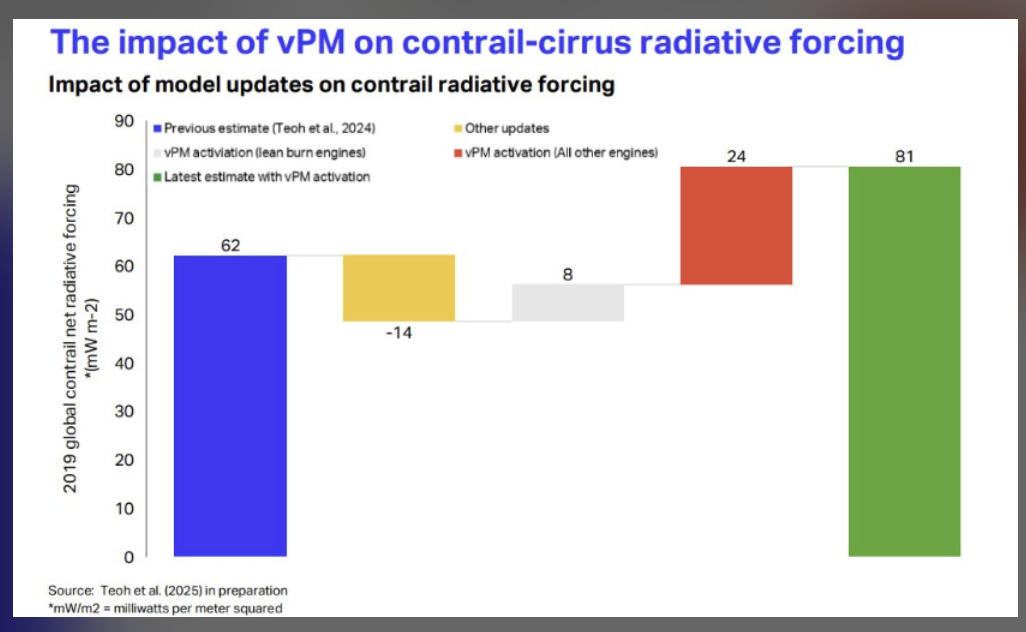

In [22]:
def joule_to_mW_per_m2(E):
    R = 6371                           # km, Earth average radius
    A = 4 * 3.1415 * R * R * 1e6       # Earth surface in m^2
    W = E / (365 * 24 * 60 * 60) * 1e3 # Annual radiation work in mW
    return W/A                         # forcing in mW/m^2 

f1 = joule_to_mW_per_m2(E = 999e18) # Annual energy forcing in J from Roger's publication
f2 = joule_to_mW_per_m2(E = 779e18) # Annual energy forcing in J from Roger's publication
f1, f2, f1-14                       # The 778e18 J figure closely matches this figure

(62.10786720404258, 48.43045901096013, 48.10786720404258)

## Plot maps

In [45]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

OUTDIR = "aggregated"

def plot_map(ds, var="seg_length_km", title="", cbar_label = "", vmin=None, vmax=None, savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """
    # --- Sum over altitude / flight levels ---
    if var == "forcing_per_dist": 
        data_2d_forcing = ds["ef_initial_loc_overlap"].sum(dim="altitude").squeeze()
        data_2d_dist    = ds["total_flight_dist"     ].sum(dim="altitude").squeeze()
        data_2d         = xr.where(data_2d_dist != 0, data_2d_forcing / data_2d_dist, 0)
    else: 
        data_2d = ds[var].sum(dim="altitude").squeeze()

    # Replace zeros with NaN for clarity
    #data_2d = data_2d.where(data_2d != 0).values

    lon = ds.longitude.values
    lat = ds.latitude.values

    proj = ccrs.PlateCarree()

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": proj},
        figsize=(7.94*2, 5.75*2)
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_2d.T,  # transpose to match lon/lat orientation
        origin="lower",
        cmap="gist_heat_r",
        transform=proj,
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        vmin=vmin,
        vmax=vmax
    )   
    
    plt.axis('off')


    # --- Save to PNG ---
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0)


    
    plt.show()

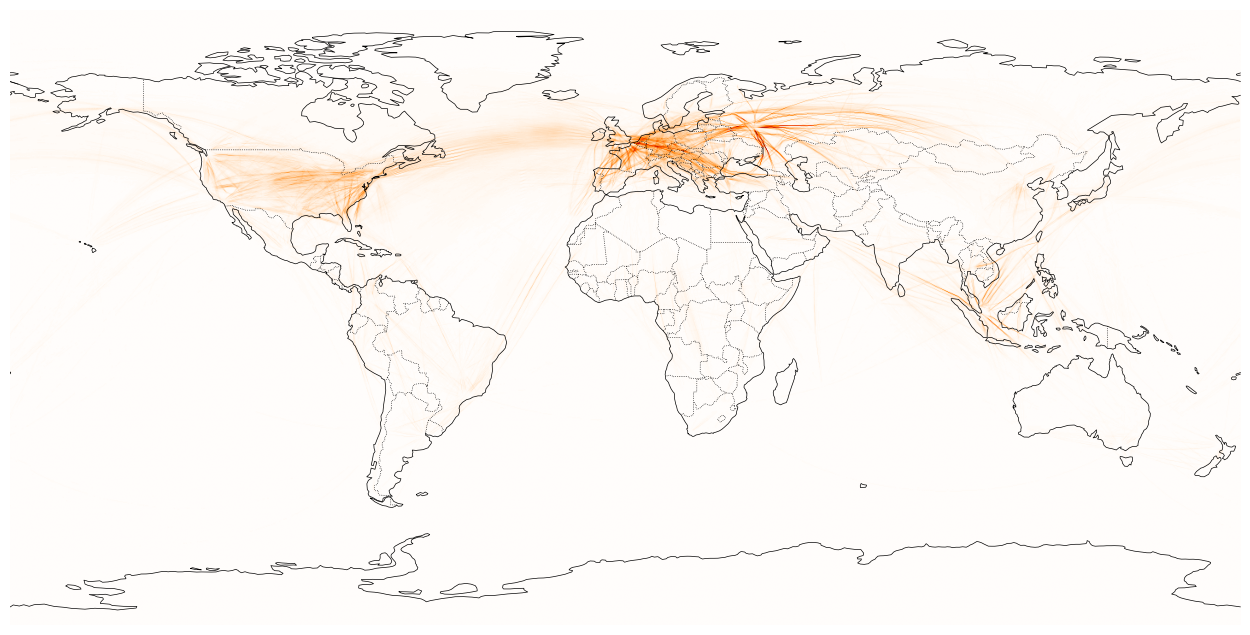

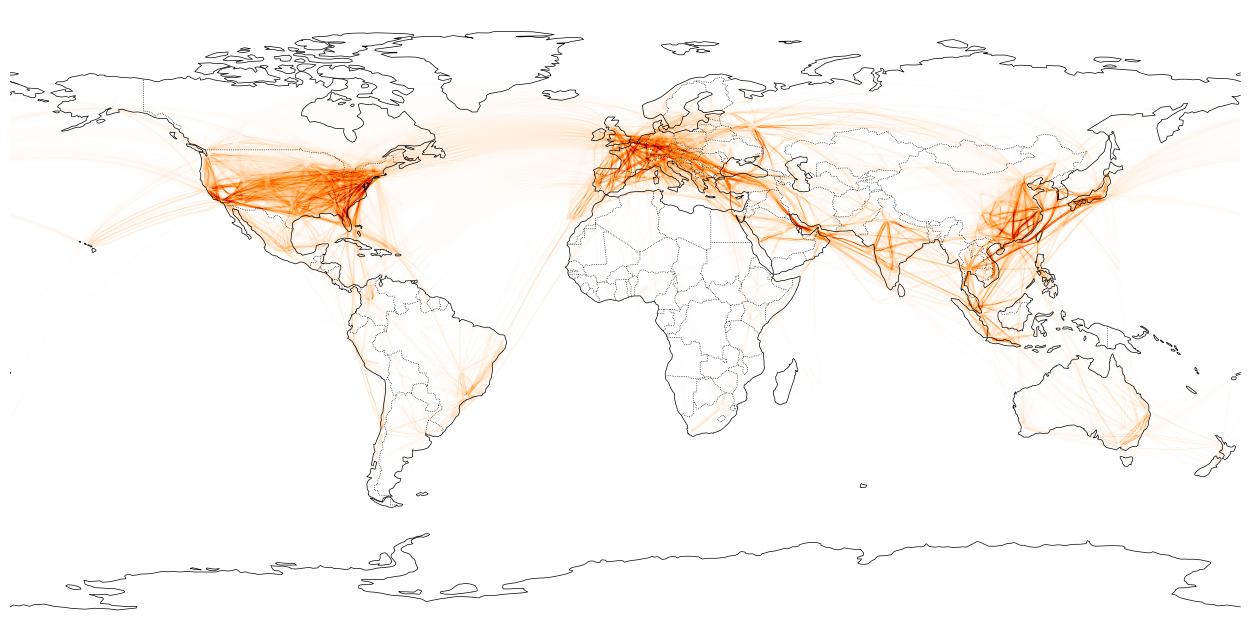

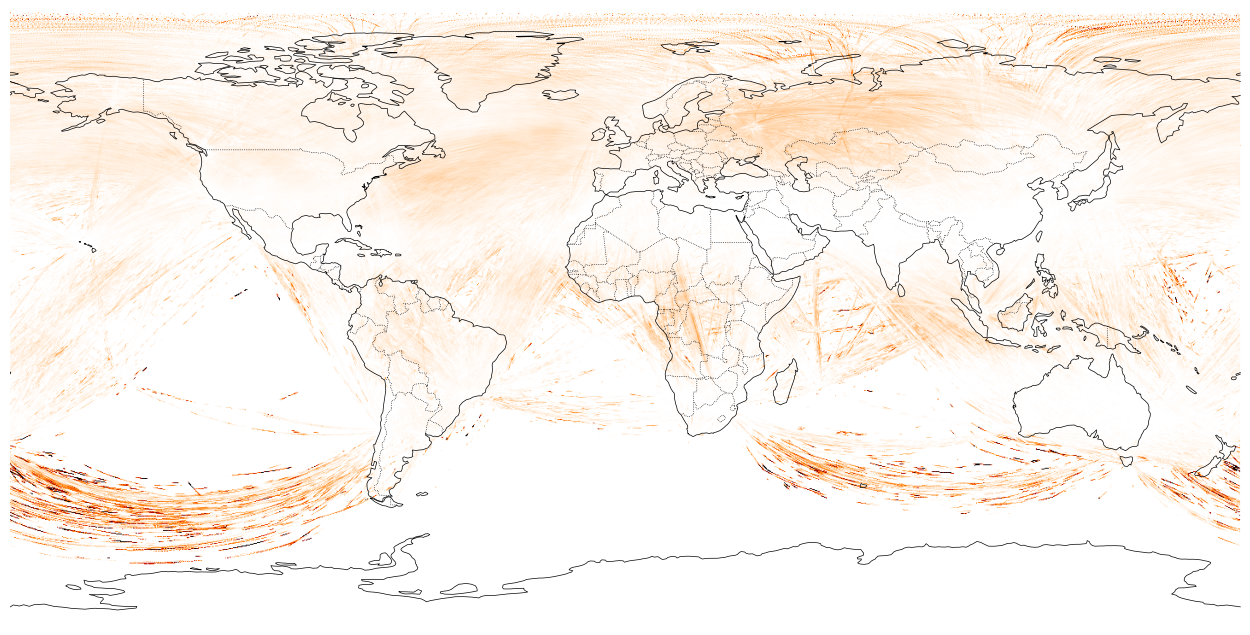

In [46]:
import xarray as xr 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")
plot_map(ds, var="ef_initial_loc_overlap", title="Global Contrail Warming", cbar_label="Energy forcing in J")
plot_map(ds, var="total_flight_dist",      title="Global Flight Distance", cbar_label="Flight distance in km")
plot_map(ds, var="forcing_per_dist",       title="Global Contrail Warming Per Flight Distance", vmin = 0, vmax=1e12, cbar_label="Energy forcing per flight distance in J/km")

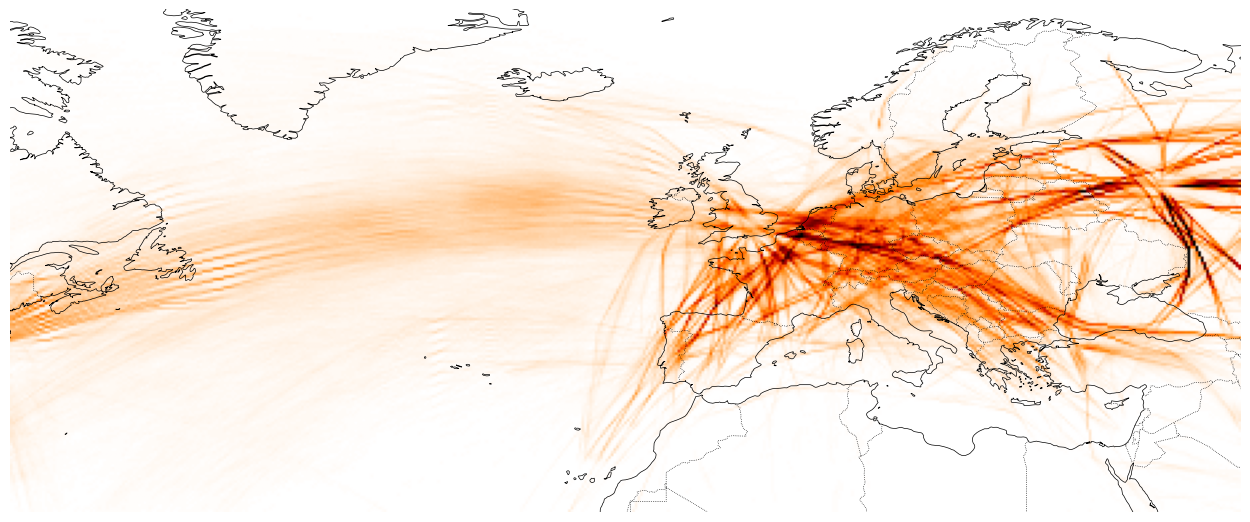

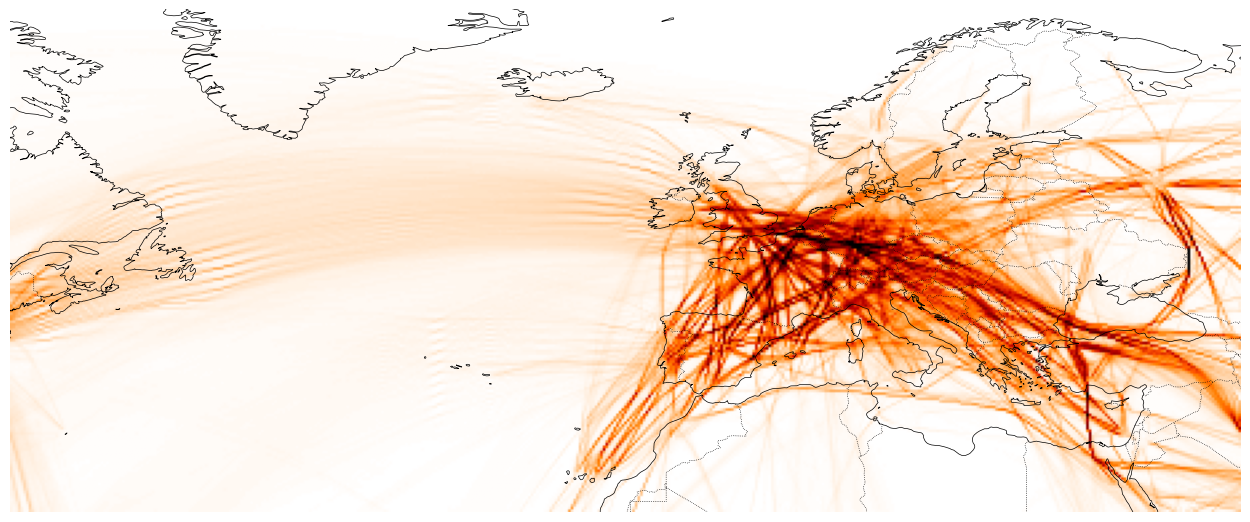

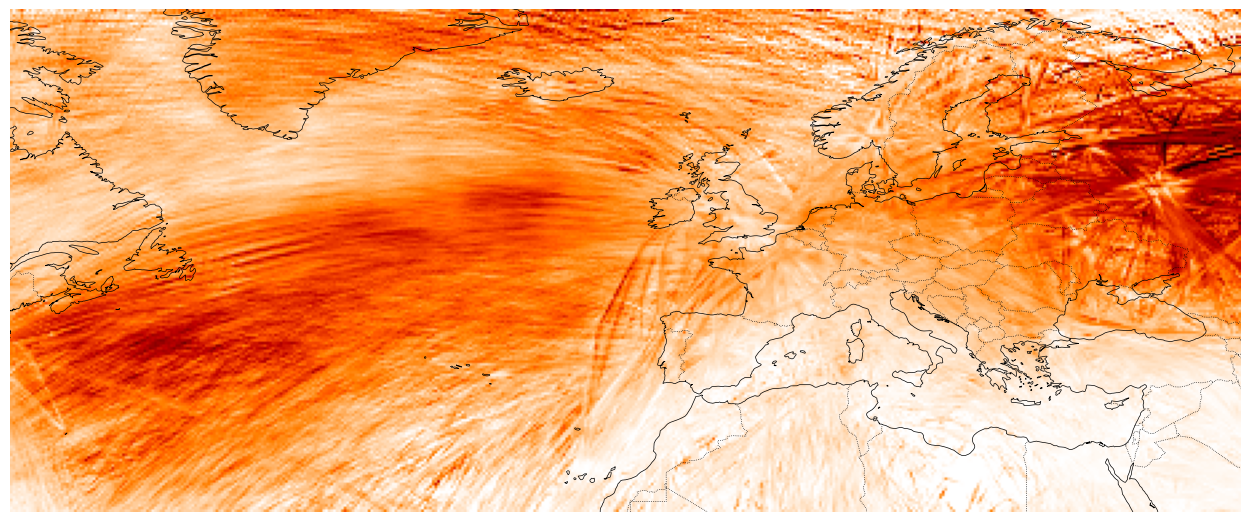

In [49]:
import xarray as xr 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")
plot_map(subset_region(ds, regions["Eurocontrol + North Atlantic"]), var="ef_initial_loc_overlap", vmin=0,      vmax = 1e17, title="North Atlantic Contrail Warming",             cbar_label="Energy forcing in J", savepath="output/forcing/4_eurocontrol_warming_map.png")
plot_map(subset_region(ds, regions["Eurocontrol + North Atlantic"]), var="total_flight_dist",      vmin=0,      vmax = 3e6,  title="North Atlantic Flight Distance",              cbar_label="Flight distance in km", savepath="output/forcing/4_eurocontrol_flight_distance_map.png")
plot_map(subset_region(ds, regions["Eurocontrol + North Atlantic"]), var="forcing_per_dist",       vmin=0,                   title="Global Contrail Warming Per Flight Distance", cbar_label="Energy forcing per flight distance in J/m", savepath="output/forcing/4_eurocontrol_warming_per_flight_distance_map.png")

## Traffic by flight level

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

def make_fl_bands(fl_step=10, fl_max=500):
    """
    Generate a dictionary of flight level bands in meters.

    Parameters
    ----------
    fl_step : int
        Step size in flight levels (hundreds of feet), e.g. 25 = 2500 ft.
    fl_max : int
        Maximum flight level (hundreds of feet), e.g. 500 = 50,000 ft.

    Returns
    -------
    dict
        Keys: band labels (e.g. 'FL000–025'), 
        Values: (lower_alt_m, upper_alt_m) tuples.
    """
    ft_to_m = 0.3048  # 1 ft = 0.3048 m
    fl_bands = {}
    for fl in range(0, fl_max, fl_step):
        fl_next = fl + fl_step
        label = f"FL{fl:03d}"
        fl_bands[label] = ((fl - fl_step/2)* 100 * ft_to_m, (fl + fl_step/2) * 100 * ft_to_m)
    return fl_bands

def aggregate_by_flight_level(ds, var="total_flight_dist"):
    # --- Define finer flight level bands (in meters) ---
    fl_bands = make_fl_bands()

    # --- Sum horizontally first ---
    var_sum = ds[var].sum(dim=["longitude", "latitude"])
    alt = ds["altitude"]

    # --- Aggregate per band ---
    var_agg = []
    labels = []

    for fl_label, (zmin, zmax) in fl_bands.items():
        mask = (alt >= zmin) & (alt < zmax)
        if mask.any():
            var_band = var_sum.where(mask, drop=True).sum()
            var_agg.append(var_band.item())
            labels.append(fl_label)

    return labels, np.array(var_agg)

l1, v1 = aggregate_by_flight_level(subset_region(ds, regions["Eurocontrol"]), var="total_flight_dist")
l2, v2 = aggregate_by_flight_level(subset_region(ds, regions["Eurocontrol"]), var="ef_initial_loc_overlap")
df = pd.DataFrame({
    "Flight level":                            l1, 
    "Flight distance in 10^9 km":              v1/1e9, 
    "Contrail warming in 10^18 J":             v2/1e18, 
    "Warming per flight distance in 10^9 J/m": v2/v1/1e9
    })
df.to_csv("output/forcing/5_eurocontrol_flight_levels", index=False)
df

,Flight level,Flight distance in 10^9 km,Contrail warming in 10^18 J,Warming per flight distance in 10^9 J/m
0,FL200,0.053180,0.000000e+00,0.000000
1,FL210,0.123885,0.000000e+00,0.000000
2,FL220,0.139825,1.211274e-03,0.008663
3,FL230,0.142355,1.333735e-02,0.093691
4,FL240,0.165597,3.536703e-02,0.213572
5,FL250,0.179911,8.259057e-02,0.459064
6,FL260,0.165798,1.727707e-01,1.042054
7,FL270,0.156811,2.693683e-01,1.717795
8,FL280,0.171324,5.516058e-01,3.219656
9,FL290,0.191309,1.205990e+00,6.303880


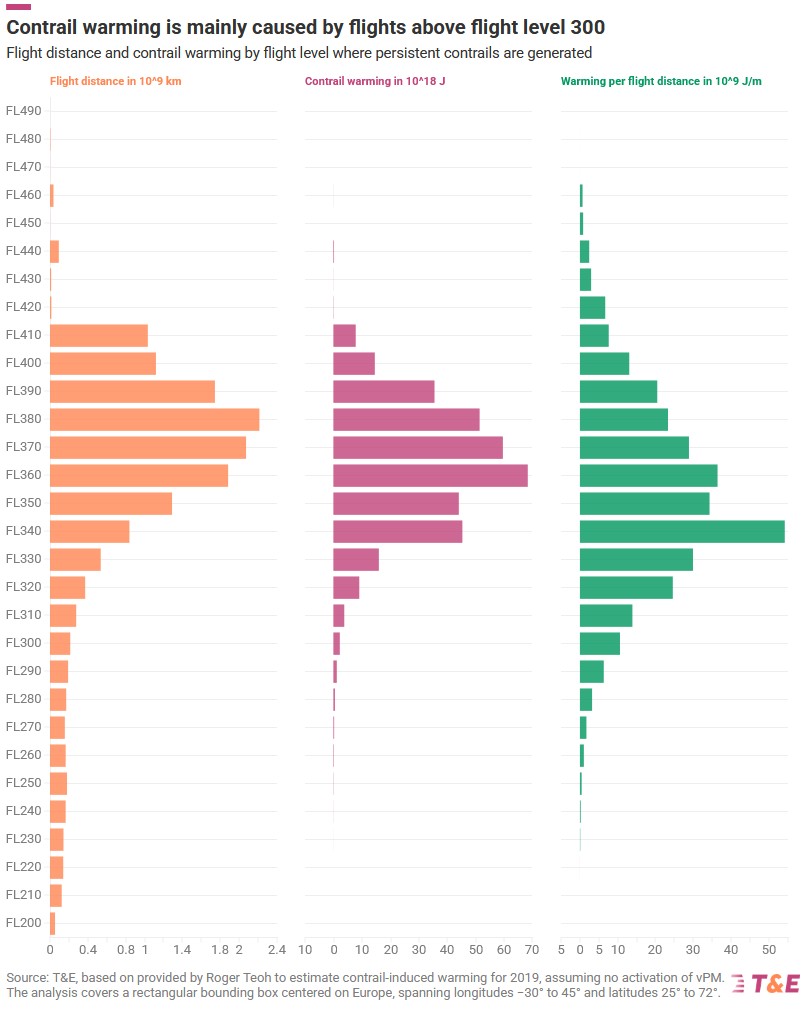

## Forcing by hour

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region_subset.pq")

df_g = df[df["region"] == "Global"]

,hour,total_flight_dist,contrail_ef_initial_loc,contrail_ef_overlap_initial_loc,new_contrail_length,total_contrail_length,tau_contrail_area,mean_contrail_age,contrail_ef,contrail_ef_sw,contrail_ef_lw,contrail_ef_overlap,contrail_ef_sw_overlap,contrail_ef_lw_overlap,timestamp,region,file
0,0,5.346956e+08,9.628866e+15,9.459706e+15,1.516372e+07,70099808.0,6.573805e+10,19554.065126,1.205451e+16,0.000000e+00,1.204241e+16,1.185265e+16,0.000000e+00,1.184374e+16,2019-01-01 00:00:00,European Airspace,20190101.pq
1,1,6.230066e+07,2.872262e+15,2.859322e+15,5.591348e+06,5429462.0,2.777793e+09,125.530231,8.382463e+13,0.000000e+00,9.842871e+13,8.478976e+13,0.000000e+00,9.957785e+13,2019-01-01 01:00:00,European Airspace,20190101.pq
2,2,9.170379e+07,4.958876e+15,4.917720e+15,9.942060e+06,13344594.0,1.183110e+10,660.376819,1.045010e+15,0.000000e+00,1.118747e+15,1.040897e+15,0.000000e+00,1.114157e+15,2019-01-01 02:00:00,European Airspace,20190101.pq
3,3,1.060297e+08,4.220226e+15,4.212467e+15,7.775997e+06,17978534.0,1.764612e+10,1335.462579,2.371746e+15,0.000000e+00,2.427070e+15,2.354567e+15,0.000000e+00,2.409406e+15,2019-01-01 03:00:00,European Airspace,20190101.pq
4,4,1.402833e+08,3.042253e+15,3.050949e+15,1.482973e+07,27608974.0,3.062147e+10,2064.185059,3.594629e+15,-3.099140e+12,3.676506e+15,3.568084e+15,-2.926518e+12,3.649087e+15,2019-01-01 04:00:00,European Airspace,20190101.pq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2285838,19,1.538820e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2019-12-31 19:00:00,Shenyang FIR,20191231.pq
2285839,20,1.436629e+07,1.186756e+08,1.186756e+08,2.749870e+04,0.0,0.000000e+00,0.000000,1.186756e+08,0.000000e+00,3.788584e+08,1.186756e+08,0.000000e+00,3.788584e+08,2019-12-31 20:00:00,Shenyang FIR,20191231.pq
2285840,21,6.230869e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2019-12-31 21:00:00,Shenyang FIR,20191231.pq
2285841,22,1.891688e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2019-12-31 22:00:00,Shenyang FIR,20191231.pq


In [2]:

df_g = df[df["region"] == "Global"]

df_g["contrail_ef_initial_loc"].sum()

np.float32(8.29483e+20)

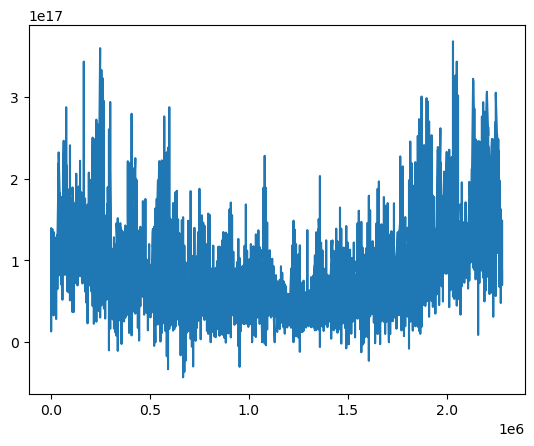

In [6]:
plt.plot(df_g["contrail_ef_overlap_initial_loc"])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region_subset.pq")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute hourly aggregates
df_hourly = (
    df
    .groupby(["region", df["timestamp"].dt.hour.rename("hour")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

df = pd.DataFrame({
    "Hour":                                    df_hourly["hour"], 
    "Flight distance in 10^9 km":              df_hourly["total_flight_dist"]/1e9, 
    "Contrail warming in 10^18 J":             df_hourly["contrail_ef_overlap_initial_loc"]/1e18, 
    "Warming per flight distance in 10^9 J/m": df_hourly["contrail_ef_overlap_initial_loc"]/df_hourly["total_flight_dist"]/1e6,
    "Region":                                  df_hourly["region"]
    }).round(4)

df.to_csv("output/forcing/6_forcing_by_hour.csv", index=False)

df

,Hour,Flight distance in 10^9 km,Contrail warming in 10^18 J,Warming per flight distance in 10^9 J/m,Region
0,0,264.352112,10.5609,39.9502,European Airspace
1,1,229.438995,7.7140,33.6211,European Airspace
2,2,232.955597,5.9937,25.7289,European Airspace
3,3,265.069000,5.8733,22.1575,European Airspace
4,4,311.615204,5.9621,19.1329,European Airspace
...,...,...,...,...,...
6427,12,0.033400,0.0000,0.1768,Nauru FIR
6428,13,0.049700,0.0001,2.1921,Nauru FIR
6429,4,0.005100,0.0001,12.6145,Bujumbura FIR
6430,15,0.004800,0.0000,2.1882,Bujumbura FIR


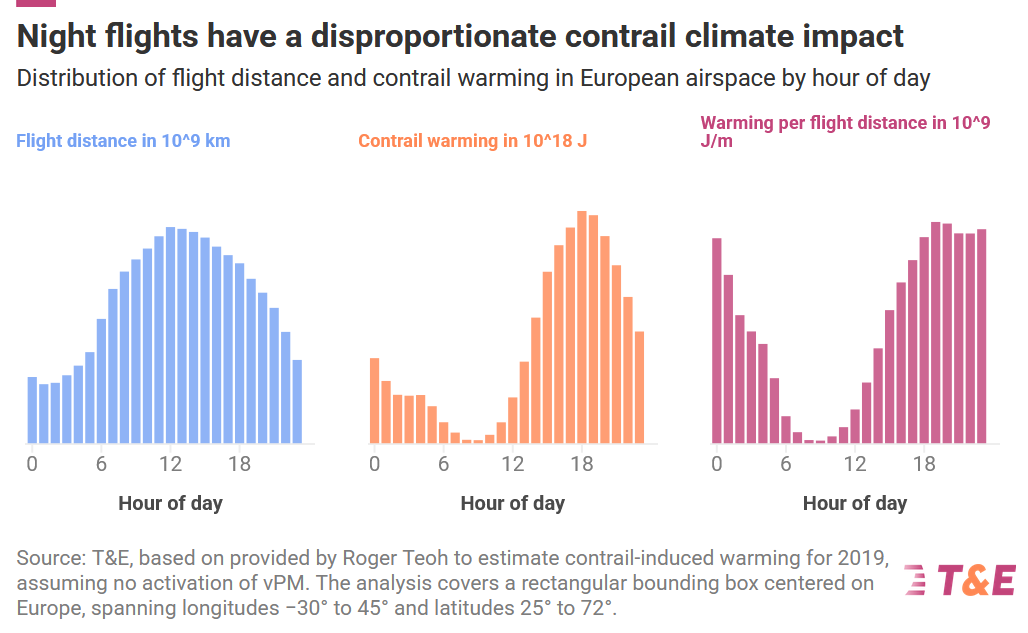

## Monthly statistics

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region_subset.pq")

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute monthly aggregates
df_monthly = (
    df
    .groupby([df["region"], df["timestamp"].dt.to_period("M")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

# Convert period to timestamp for plotting
df_monthly["timestamp"] = df_monthly["timestamp"].dt.to_timestamp()


df = pd.DataFrame({
    "Month":                                   df_monthly["timestamp"].dt.month.map(month_map), 
    "Flight distance in 10^9 km":              df_monthly["total_flight_dist"]/1e9, 
    "Contrail warming in 10^18 J":             df_monthly["contrail_ef_overlap_initial_loc"]/1e18, 
    "Warming per flight distance in 10^9 J/m": df_monthly["contrail_ef_overlap_initial_loc"]/df_monthly["total_flight_dist"]/1e6,
    "Region":                                  df_monthly["region"]
    }).round(2)

df.to_csv("output/forcing/7_forcing_by_month.csv", index=False)

df

,Month,Flight distance in 10^9 km,Contrail warming in 10^18 J,Warming per flight distance in 10^9 J/m,Region
0,Jan,1054.239990,37.25,35.33,European Airspace
1,Jan,209.679993,14.36,68.46,North Atlantic
2,Jan,590.460022,13.68,23.17,Continental Europe
3,Jan,4781.209961,91.29,19.09,Global
4,Jan,1178.810059,12.15,10.31,USA
...,...,...,...,...,...
3211,Dec,13.600000,0.38,28.18,Ulaanbaatar FIR
3212,Dec,67.779999,0.04,0.52,Kunming FIR
3213,Dec,146.380005,0.24,1.67,Shanghai FIR
3214,Dec,13.070000,0.46,35.16,Urumqi FIR


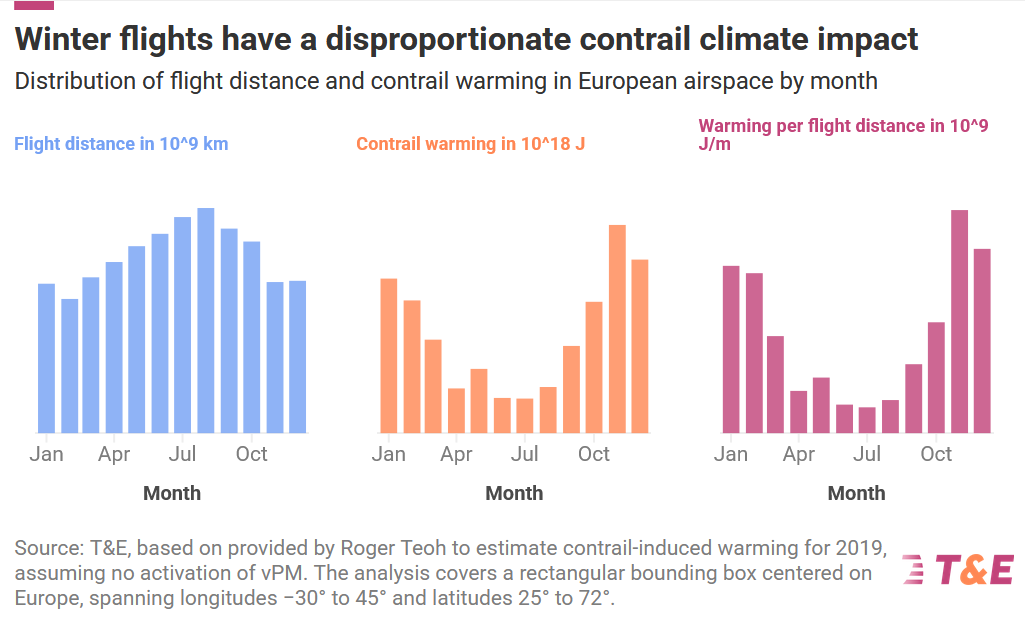

## Forcing by FIR

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region_subset.pq")

# Compute monthly aggregates
df_fir = (
    df
    .groupby("region")
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

df_fir = df_fir[df_fir["region"].str.contains("FIR")]
df = pd.DataFrame({
    "Flight Information Region":               df_fir["region"],
    "Contrail Warming (×10¹⁸ J)":             df_fir["contrail_ef_overlap_initial_loc"]/1e18, 
    "Flight Distance (×10⁹ km)":              df_fir["total_flight_dist"]/1e9, 
    "Contrail Warming per Distance (×10⁹ J/m)": df_fir["contrail_ef_overlap_initial_loc"]/df_fir["total_flight_dist"]/1e6,
    }).round(2)


df.to_csv("output/forcing/8_forcing_by_fir.csv", index=False)

df

,Flight Information Region,Contrail Warming (×10¹⁸ J),Flight Distance (×10⁹ km),Contrail Warming per Distance (×10⁹ J/m)
0,Accra FIR,0.62,864.179993,0.71
1,Addis Abeba FIR,0.64,61.580002,10.38
3,Aktobe FIR,5.97,99.779999,59.80
4,Alaska FIR,10.08,396.540009,25.43
5,Albuquerque FIR,3.83,853.909973,4.48
...,...,...,...,...
263,Yakutsk FIR,2.19,97.970001,22.40
264,Yangon FIR,1.45,205.110001,7.06
265,Yekaterinburg FIR,13.17,192.020004,68.61
266,Yerevan FIR,0.11,10.870000,10.46


## How busy is airspace when contrails occur?

In [32]:
firs

,name,designator,Eurocontrol FIR,type,upper,lower,geometry
0,European Airspace,None,None,RECT,NaN,NaN,"POLYGON ((45 25, 45 72, -30 72, -30 25, 45 25))"
1,North Atlantic,None,None,RECT,NaN,NaN,"POLYGON ((-5 40, -5 63, -70 63, -70 40, -5 40))"
2,Continental Europe,None,None,RECT,NaN,NaN,"POLYGON ((20 35, 20 60, -12 60, -12 35, 20 35))"
3,Global,None,None,RECT,NaN,NaN,"POLYGON ((180 -90, 180 90, -180 90, -180 -90, ..."
4,USA,None,None,RECT,NaN,NaN,"POLYGON ((-66 23, -66 50, -126 50, -126 23, -6..."
...,...,...,...,...,...,...,...
263,Ulaanbaatar FIR,ZMUB,False,FIR,NaN,0.0,"POLYGON ((87.98319 49.18334, 87.83343 49.1666,..."
264,Kunming FIR,ZPKM,False,FIR,NaN,0.0,"POLYGON ((105.54185 23.19581, 105.79997 24.650..."
265,Shanghai FIR,ZSHA,False,FIR,NaN,0.0,"POLYGON ((124.00014 37.99993, 123.00006 38.249..."
266,Urumqi FIR,ZWUQ,False,FIR,NaN,0.0,"POLYGON ((96.33736 42.91663, 96.16672 42.99997..."


In [ ]:

import geopandas

['Reykjavik FIR',
 'Brussels FIR',
 'Langen FIR',
 'Munchen FIR',
 'Bremen FIR',
 'Tallinn FIR',
 'Helsinki FIR',
 'Shanwick FIR',
 'Scottish FIR',
 'London FIR',
 'Amsterdam FIR',
 'Shannon FIR',
 'Copenhagen FIR',
 'Bodo Oceanic FIR',
 'Polaris FIR',
 'Warszawa FIR',
 'Sweden FIR',
 'Riga FIR',
 'Vilnius FIR',
 'Canarias FIR',
 'Tirana FIR',
 'Sofia FIR',
 'Nicosia FIR',
 'Zagreb FIR',
 'Barcelona FIR',
 'Madrid FIR',
 'Bordeaux FIR',
 'Reims FIR',
 'Paris FIR',
 'Marseille FIR',
 'Brest FIR',
 'Athinai FIR',
 'Budapest FIR',
 'Brindisi FIR',
 'Milano FIR',
 'Roma FIR',
 'Ljubljana FIR',
 'Praha FIR',
 'Malta FIR',
 'Wien FIR',
 'Lisboa FIR',
 'Santa Maria FIR',
 'Sarajevo FIR',
 'Bucarest FIR',
 'Switzerland FIR',
 'Ankara FIR',
 'Istanbul FIR',
 'Chisinau FIR',
 'Skopje FIR',
 'Beograd FIR',
 'Bratislava  FIR',
 'Yerevan FIR',
 'Tibilisi FIR',
 'Kiev FIR',
 'Dnipro FIR',
 'Simferopol FIR',
 'Lvov FIR',
 'Odessa FIR']

In [ ]:
import pandas as pd
import numpy as np
import geopandas 

# Load your data
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region_subset.pq")

# Function to compute cumulative and percent values for one region
def compute_region_metrics(df_region):
    df_sorted = df_region.sort_values("total_flight_dist", ascending=False).reset_index(drop=True)
    
    df_sorted["cum_flight"]      = df_sorted["total_flight_dist"].cumsum()
    df_sorted["cum_heating"]     = df_sorted["contrail_ef_overlap_initial_loc"].cumsum()
    df_sorted["cum_heating_pct"] = df_sorted["cum_heating"] / df_sorted["cum_heating"].iloc[-1] * 100
    df_sorted["tot_flight_pct"]  = df_sorted["total_flight_dist"] / df_sorted["total_flight_dist"].max() * 100
    df_sorted["block_pct"] = np.linspace(0, 100, len(df_sorted))

    # Final dataframe with visualization-friendly column names
    df_vis = (
        df_sorted[["region", "block_pct", "tot_flight_pct", "cum_heating_pct"]]
        .iloc[::96]
        .rename(columns={
            "region":          "Region",
            "block_pct":       "Hour of year",
            "tot_flight_pct":  "Airspace 'business'",
            "cum_heating_pct": "Cumulative contrail warming"
        })
    )

    return df_vis

# Apply to each region and concatenate results
results = []
for region, df_region in df.groupby("region", sort=False):
    region_df = compute_region_metrics(df_region)
    results.append(region_df)

df_all_regions = pd.concat(results, ignore_index=True).round(4)

# Export to CSV
output_path = "output/forcing/9_cum_heating_vs_business.csv"
df_all_regions.to_csv(output_path, index=False)

print(f"✅ CSV exported to {output_path}")


✅ CSV exported to output/forcing/9_cum_heating_vs_business.csv


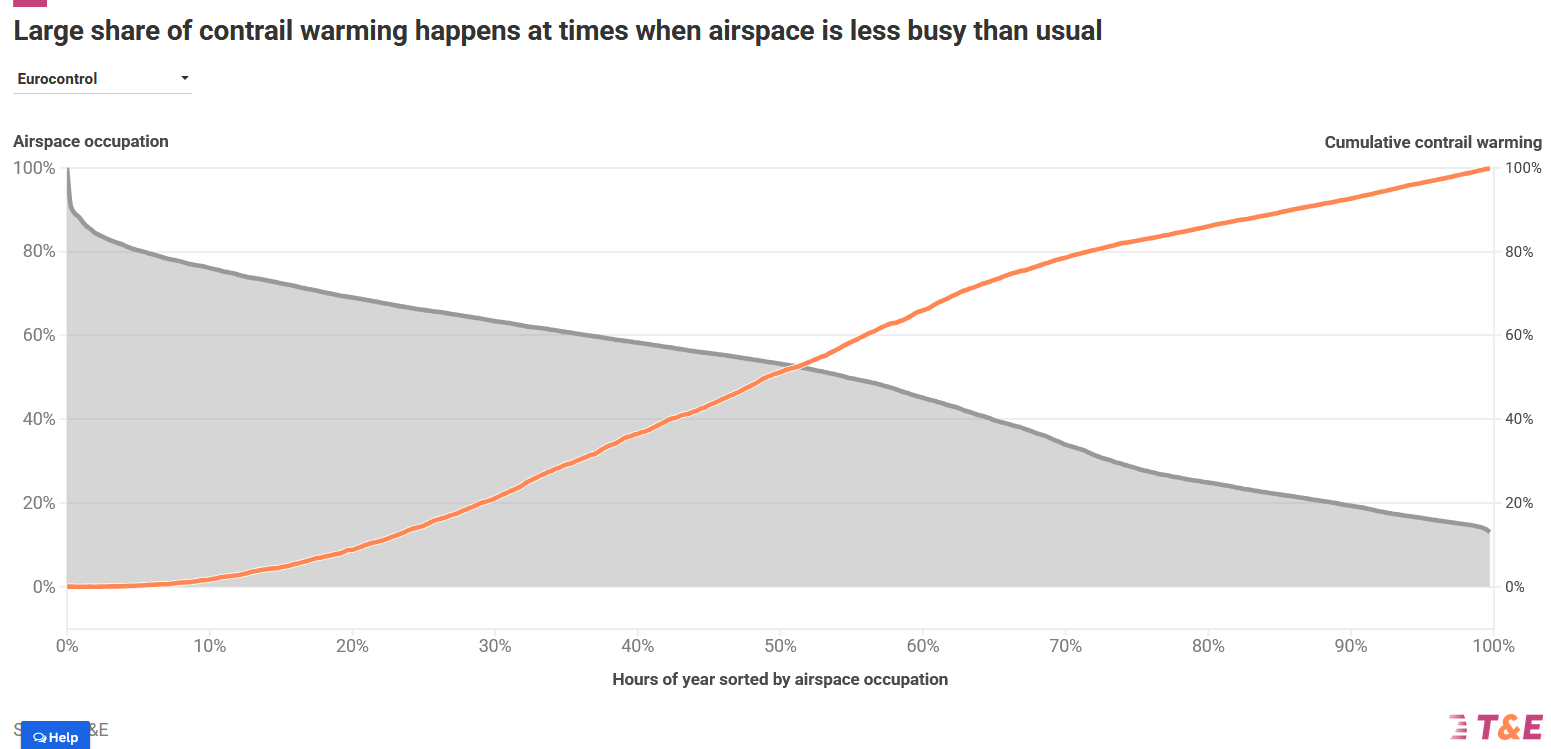